### Genral Import

In [68]:
# general
import os
import numpy as np
import pandas as pd
import seaborn as sns

# plots
from IPython.display import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from IPython.display import Image

# predictions
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
%matplotlib inline

### Define classes

In [2]:
class Perceptron_self(object):
    """ Perceptron classifier
    # param eta: float, learning rate (between 0.0 and 1.0)
    # param n_iter: int, passes over the training dataset
    # param random_state: int, random number generator seed for random weight initialization

    # attribute w_: 1d-array, weights after fitting
    # attribute errors_: list, number of misclasifications (updates) in each epoch
    """

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data
        # param X:array-like, shape = [n_examples, n_features]
        # param y: array_like, shape =[n_examples]
        # return self: object
        """

        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, -1)

### Define functions

In [3]:
def plot_decision_regions(X, y, classifier, plot_test, resolution=0.02):
    """ Plot decission regions, perceptron model
    # param X: <<your task to comment here>>
    # param y: <<your task to comment here>>
    # param classifier: <<your task to comment here>>
    # param plot_test: integer, 1 if plot test sample, 0 otherwise
    # param resolution: <<your task to comment here>>
    # return: None
    """

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=cl,
                    edgecolor='black')

    # highlight text examples
    if plot_test == 1:
        test_idx = range(105, 150)
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100,
                    label='test set')


___
### ### Classification to identify phishing URLs. The given URL is blocked if its USI is >=80 and <100
___

### Business Understanding

In today's increasingly digital world, the rapid growth of online services has made phishing attacks a major cybersecurity threat, targeting individuals and organizations through deceptive URLs designed to steal sensitive information. This dataset was collected to support the development of machine learning models capable of identifying phishing URLs based on URL structure and behavior, addressing the limitations of traditional rule-based systems. The primary goal is to accurately classify URLs as phishing or legitimate, enabling real-time protection against cyber threats. The effectiveness of a good prediction algorithm can be measured by its accuracy, precision, recall, and ability to generalize to new, evolving phishing tactics. This data is critical for building adaptive security solutions that can protect users and systems from financial loss, data breaches, and reputational damage caused by phishing attacks.

### Describe the emaning and type of data(scale, values, etc) for each attribute in the data file

### Read data

Phishing dataset: https://archive.ics.uci.edu/static/public/967/phiusiil+phishing+url+dataset.zip

In [4]:
# Local importing of dataset

# import os
# import pandas as pd

# # Get the current working directory
# current_directory = os.getcwd()

# # Path to the CSV file relative to the current directory
# file_path = os.path.join(current_directory, 'Data', 'PhiUSIIL_Phishing_URL_Dataset.csv')

# # Read the local CSV file
# df = pd.read_csv(url, encoding='utf-8')

# print('\nShape of data:', df.shape)
# df.head()

In [41]:
import pandas as pd

# URL to the dataset
url = 'https://archive.ics.uci.edu/static/public/967/phiusiil+phishing+url+dataset.zip'

# Read the CSV file from the URL, ignoring the first column (index 0)
df = pd.read_csv(url, encoding='utf-8')
df = df.drop('FILENAME', axis=1) # Column "FILENAME" can be ignored.
print('\nShape of data:', df.shape)
df.head()



Shape of data: (235795, 55)


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [6]:
# print lablels
df["label"].unique() # Label 1 corresponds to a legitimate URL, label 0 to a phishing URL

array([1, 0], dtype=int64)

### Data types

In [7]:
print((df.dtypes == np.int64).sum())
print((df.dtypes == np.float64).sum())
print((df.dtypes == np.object).sum())

41
10
4


c:\ProgramData\anaconda3\envs\ML7331\lib\site-packages\ipykernel_launcher.py:3: DeprecationWarning: `np.object` is a deprecated alias for the builtin `object`. To silence this warning, use `object` by itself. Doing this will not modify any behavior and is safe. 
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  This is separate from the ipykernel package so we can avoid doing imports until


In [8]:
print(df.dtypes)

URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode                      int64
LargestLineL

There are in total 55 columns including target/response variable label.
There are three types.
- continuous: 10
- Integer(Discrete): 41
- Categorical: 4

For now the integer types includes binary categorical columns that have values as 0 or 1.


### Data Statistics

In [42]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


### Separate columns by type
- numeric columns
- binary columns
- categorical columns that has more than 2 values.

In [46]:
# Numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
print("Numeric columns:", list(numeric_cols))



# Categorical columns (object, category, bool)
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
print("Categorical columns:", list(categorical_cols))


# Step 2: Identify binary columns (only 2 unique values, like 0 and 1)
binary_categorical_cols = [col for col in numeric_cols if df[col].nunique(dropna=False) == 2]

# Step 3: Get true continuous numeric columns
continuous_numeric_cols = [col for col in numeric_cols if col not in binary_categorical_cols]

print("Binary Categorical Columns (0/1 type):", binary_categorical_cols)
print("Continuous Numeric Columns:", continuous_numeric_cols)


Numeric columns: ['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']
Categorical columns: ['URL', 'Domain', 'TLD', 'Title']
Binary Categorical Columns (0/1 type): ['IsDomainIP', 

In [11]:
print(len(numeric_cols))
print(len(binary_categorical_cols))
print(len(continuous_numeric_cols))
print(len(categorical_cols))

51
20
31
4


If we isolate that binary categorical out as categorical, the count will be following.
- continuous: 10
- Integer(Discrete): 21
- Categorical: 24

### Meaning of the data
- label : target variable, Label 1 corresponds to a legitimate URL, label 0 to a phishing URL
- URL: Columns related to URL have URLs that were collected, number of letter, digit, number of ratio of letter and digit, number of special characeters..
- TLD: Top Level Domains, which is the last segment of the domain name.
- URLSimilarityIndex: This is for  for detecting visual similarity-based attacks.
- 


## Data Quality
### Missing data

No missing values.

In [44]:
# Check any missing values for each column
missing_info = df.isnull().sum()

# Filter and display only columns with missing values
missing_columns = missing_info[missing_info > 0]
print("Columns with missing values:\n", missing_columns)

# Total number of missing values
total_missing = missing_info.sum()
print("\nTotal number of missing values:", total_missing)

Columns with missing values:
 Series([], dtype: int64)

Total number of missing values: 0


### Duplicate Data

No duplicate data

In [13]:
# check for duplicate rows
duplicate_rows = df[df.duplicated()]
print("Number of duplicate rows:", len(duplicate_rows))
print("Duplicate rows:\n", duplicate_rows)

Number of duplicate rows: 0
Duplicate rows:
 Empty DataFrame
Columns: [URL, URLLength, Domain, DomainLength, IsDomainIP, TLD, URLSimilarityIndex, CharContinuationRate, TLDLegitimateProb, URLCharProb, TLDLength, NoOfSubDomain, HasObfuscation, NoOfObfuscatedChar, ObfuscationRatio, NoOfLettersInURL, LetterRatioInURL, NoOfDegitsInURL, DegitRatioInURL, NoOfEqualsInURL, NoOfQMarkInURL, NoOfAmpersandInURL, NoOfOtherSpecialCharsInURL, SpacialCharRatioInURL, IsHTTPS, LineOfCode, LargestLineLength, HasTitle, Title, DomainTitleMatchScore, URLTitleMatchScore, HasFavicon, Robots, IsResponsive, NoOfURLRedirect, NoOfSelfRedirect, HasDescription, NoOfPopup, NoOfiFrame, HasExternalFormSubmit, HasSocialNet, HasSubmitButton, HasHiddenFields, HasPasswordField, Bank, Pay, Crypto, HasCopyrightInfo, NoOfImage, NoOfCSS, NoOfJS, NoOfSelfRef, NoOfEmptyRef, NoOfExternalRef, label]
Index: []

[0 rows x 55 columns]


### Outliers

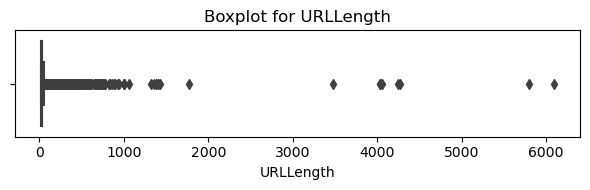

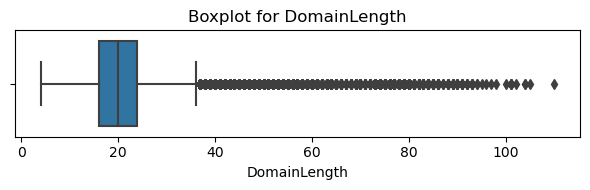

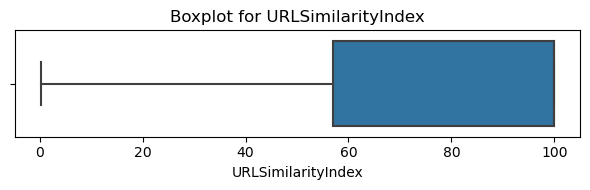

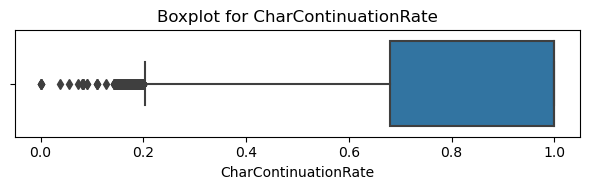

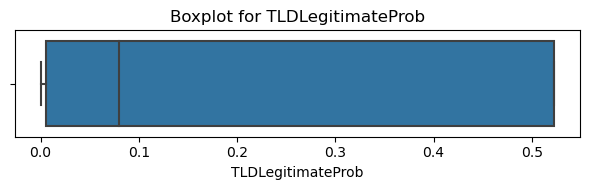

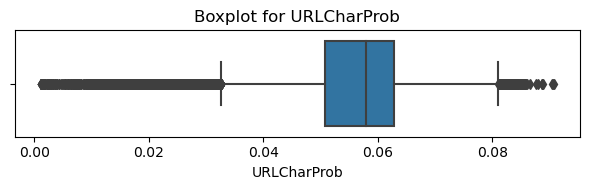

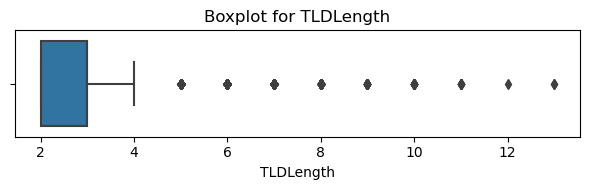

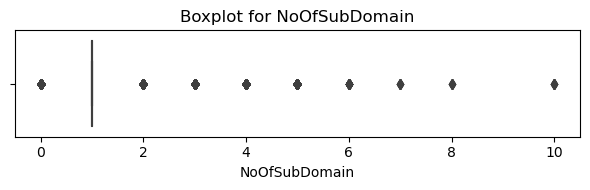

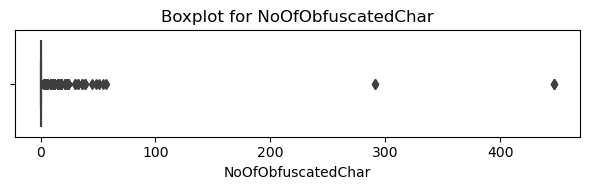

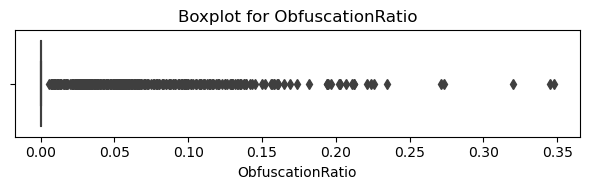

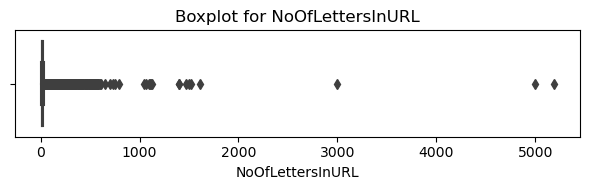

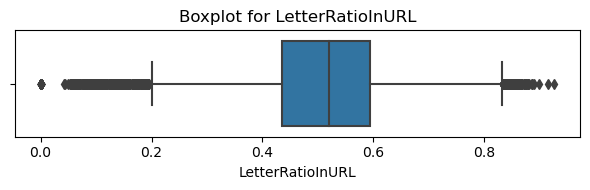

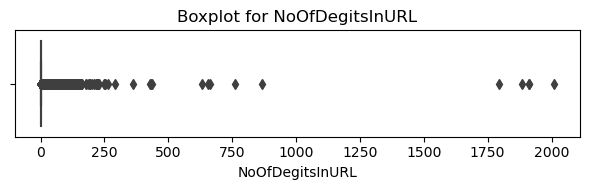

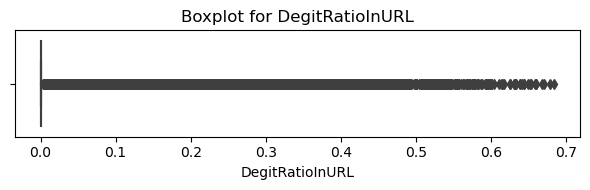

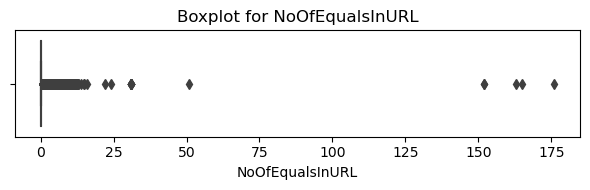

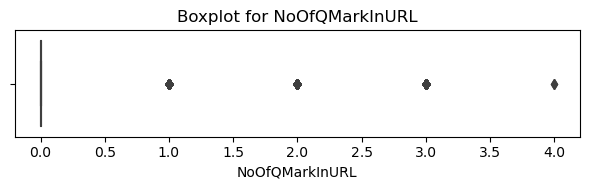

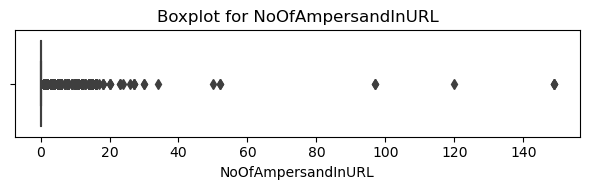

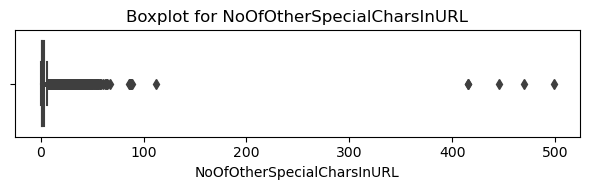

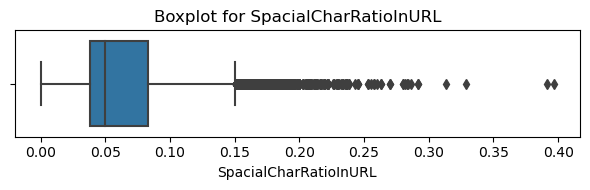

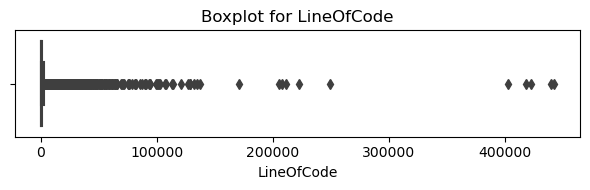

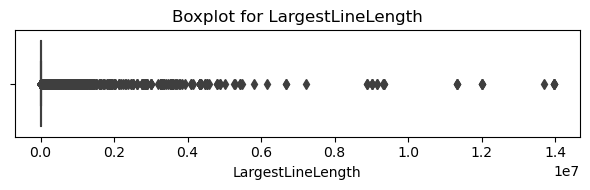

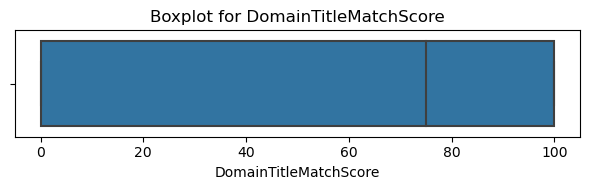

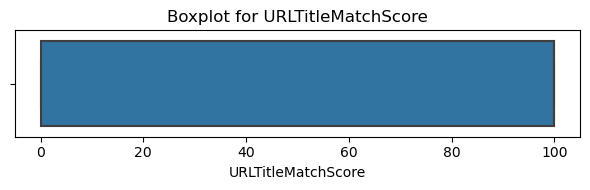

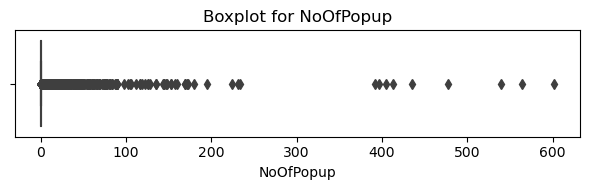

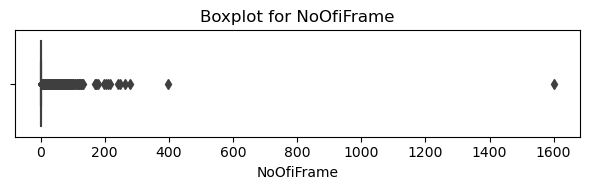

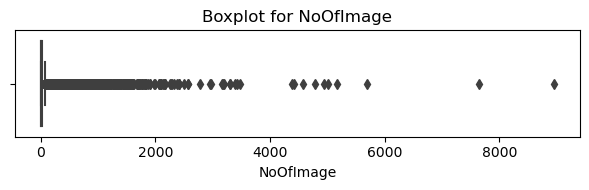

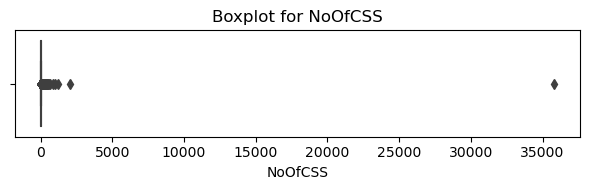

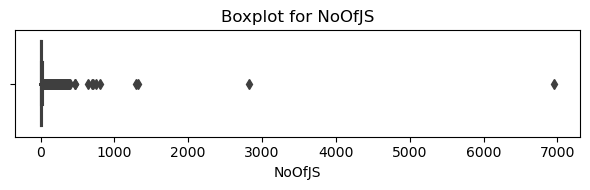

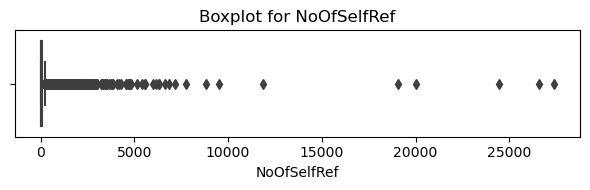

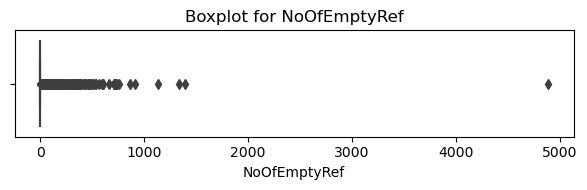

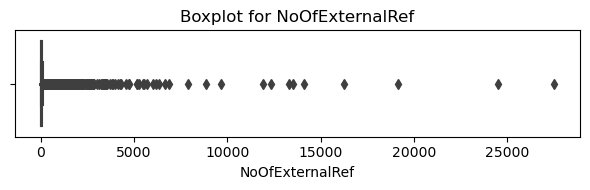

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Create boxplot for each column
for col in continuous_numeric_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot for {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


Following columns areobserved with Outliers.
- NoOfObsfuscatedChar
- Under URL related coluns:
    - NoOfObfuscatedChar
    - NoOfLettersInURL
    - NoOfDegitsInURL
    - NoOfEqualsInURL
    - NoOfOtherSpecialCharsInURL
    - LineOfCode
    - NoOfiFrame
    - NoOfCSS
    - NoOfJS
    - NoOfEmptyRef

In [57]:
outliers = df[df['NoOfObfuscatedChar'] > 250]  # Adjust condition based on your threshold
outliers['label'].value_counts(normalize=True)
# Summary of outliers vs non-outliers
df['is_outlier'] = df['NoOfObfuscatedChar'] >250   # example
df.groupby('is_outlier')['NoOfObfuscatedChar'].describe()

# See counts of phishing (0) vs legitimate (1)
print(outliers['label'].value_counts())



0    5
Name: label, dtype: int64


There are 5 outliers where NoOfObfuscatedChar exceeds the threshold, and all of them have a label value of 0, indicating phishing cases. This suggests that these outliers are not random noise but potentially strong indicators of phishing behavior. Therefore, we will retain these outliers in the dataset. For subsequent outlier analyses, a similar approach will be applied: if the outliers are predominantly labeled as phishing, they will be kept as meaningful signals; if they are mostly labeled as legitimate, they may be considered noise and subject to removal.

In [58]:
outliers = df[df['URLLength'] > 3000]  # Adjust condition based on your threshold
outliers['label'].value_counts(normalize=True)
# Summary of outliers vs non-outliers
df['is_outlier'] = df['LineOfCode'] > 3000  # example
df.groupby('is_outlier')['LineOfCode'].describe()

# See counts of phishing (0) vs legitimate (1)
print(outliers['label'].value_counts())

# See proportions
print(outliers['label'].value_counts(normalize=True))

0    8
Name: label, dtype: int64
0    1.0
Name: label, dtype: float64


In [59]:
outliers = df[df['NoOfLettersInURL'] > 2000]  # Adjust condition based on your threshold
outliers['label'].value_counts(normalize=True)
# Summary of outliers vs non-outliers
df['is_outlier'] = df['NoOfLettersInURL'] > 2000  # example
df.groupby('is_outlier')['NoOfLettersInURL'].describe()

# See counts of phishing (0) vs legitimate (1)
print(outliers['label'].value_counts())

# See proportions
print(outliers['label'].value_counts(normalize=True))

0    3
Name: label, dtype: int64
0    1.0
Name: label, dtype: float64


In [60]:
outliers = df[df['NoOfDegitsInURL'] > 1000]  # Adjust condition based on your threshold
outliers['label'].value_counts(normalize=True)
# Summary of outliers vs non-outliers
df['is_outlier'] = df['NoOfDegitsInURL'] > 1000  # example
df.groupby('is_outlier')['NoOfDegitsInURL'].describe()

# See counts of phishing (0) vs legitimate (1)
print(outliers['label'].value_counts())

# See proportions
print(outliers['label'].value_counts(normalize=True))

0    5
Name: label, dtype: int64
0    1.0
Name: label, dtype: float64


In [61]:
outliers = df[df['NoOfEqualsInURL'] > 150]  # Adjust condition based on your threshold
outliers['label'].value_counts(normalize=True)
# Summary of outliers vs non-outliers
df['is_outlier'] = df['NoOfEqualsInURL'] > 150  # example
df.groupby('is_outlier')['NoOfEqualsInURL'].describe()

# See counts of phishing (0) vs legitimate (1)
print(outliers['label'].value_counts())

# See proportions
print(outliers['label'].value_counts(normalize=True))

0    5
Name: label, dtype: int64
0    1.0
Name: label, dtype: float64


In [62]:
outliers = df[df['NoOfOtherSpecialCharsInURL'] > 150]  # Adjust condition based on your threshold
outliers['label'].value_counts(normalize=True)
# Summary of outliers vs non-outliers
df['is_outlier'] = df['NoOfOtherSpecialCharsInURL'] > 150  # example
df.groupby('is_outlier')['NoOfOtherSpecialCharsInURL'].describe()

# See counts of phishing (0) vs legitimate (1)
print(outliers['label'].value_counts())

# See proportions
print(outliers['label'].value_counts(normalize=True))

0    5
Name: label, dtype: int64
0    1.0
Name: label, dtype: float64


In [63]:
outliers = df[df['LineOfCode'] > 400000]  # Adjust condition based on your threshold
outliers['label'].value_counts(normalize=True)
# Summary of outliers vs non-outliers
df['is_outlier'] = df['LineOfCode'] > 400000  # example
df.groupby('is_outlier')['LineOfCode'].describe()

# See counts of phishing (0) vs legitimate (1)
print(outliers['label'].value_counts())

# See proportions
print(outliers['label'].value_counts(normalize=True))

1    5
Name: label, dtype: int64
1    1.0
Name: label, dtype: float64


In [64]:
outliers = df[df['NoOfiFrame'] > 1400]  # Adjust condition based on your threshold
outliers['label'].value_counts(normalize=True)
# Summary of outliers vs non-outliers
df['is_outlier'] = df['NoOfiFrame'] > 1400  # example
df.groupby('is_outlier')['NoOfiFrame'].describe()

# See counts of phishing (0) vs legitimate (1)
print(outliers['label'].value_counts())

# See proportions
print(outliers['label'].value_counts(normalize=True))

1    1
Name: label, dtype: int64
1    1.0
Name: label, dtype: float64


In [65]:
outliers = df[df['NoOfJS'] > 1000]  # Adjust condition based on your threshold
outliers['label'].value_counts(normalize=True)
# Summary of outliers vs non-outliers
df['is_outlier'] = df['NoOfJS'] > 1000  # example
df.groupby('is_outlier')['NoOfJS'].describe()


# See counts of phishing (0) vs legitimate (1)
print(outliers['label'].value_counts())

# See proportions
print(outliers['label'].value_counts(normalize=True))


1    4
Name: label, dtype: int64
1    1.0
Name: label, dtype: float64


In [66]:
outliers = df[df['NoOfEmptyRef'] > 1000]  # Adjust condition based on your threshold
outliers['label'].value_counts(normalize=True)
# Summary of outliers vs non-outliers
df['is_outlier'] = df['NoOfEmptyRef'] > 1000  # example
df.groupby('is_outlier')['NoOfEmptyRef'].describe()


# See counts of phishing (0) vs legitimate (1)
print(outliers['label'].value_counts())

# See proportions
print(outliers['label'].value_counts(normalize=True))

1    4
Name: label, dtype: int64
1    1.0
Name: label, dtype: float64


For the following colums' outliers,
- LineOfCode
- NoOfiFrame
- NoOfJS
- NoOfEmptyRef

they all have legitimate url which might mean they are noise that needs to be removed.

### label vs categorical_cols

In [15]:
# Loop through and show value counts
for col in categorical_cols:
    print(f"\nValue Counts for '{col}':")
    print(df[col].value_counts(dropna=False))  # dropna=False shows NaNs too
    



Value Counts for 'URL':
https://disclosepack.myportfolio.com/                                                         2
https://barlandas.com/reprisedefunction/unzupdm/                                              2
http://app-batasotak1244acces.kvoiffugw9-yk26ed5vg379.p.temp-site.link/termsofservice.html    2
https://fleek.ipfs.io/ipfs/qmzt2xz7uq7tdgiirmv7u7zaabtfhjn8jzouurbptgtgal/                    2
https://sucursalvirtualpersona.la-empresaempre.repl.co/                                       2
                                                                                             ..
https://www.clothdiaperkids.com                                                               1
https://www.toucansolution.com                                                                1
https://www.tirnavos.gr                                                                       1
https://www.lovehappyhour.com                                                                 1
https://www.alt

### label vs binary_categorical_cols

Unbalanced count of categorical vairables.
- HasObfuscation
- IsHTTPS
- HasTitle
- HasFavicon
- Robots
- IsResponsive
- NoOfSelfRedirect
- HasExternalFormSubmit
- HasPasswordField
- Bank
- Crypto


In [16]:
print(len(binary_categorical_cols))

20


In [17]:
# Loop through and show value counts
for col in binary_categorical_cols[1:6]:
    print(f"\nValue Counts for '{col}':")
    print(df[col].value_counts(dropna=False).to_string())  # dropna=False shows NaNs too


Value Counts for 'HasObfuscation':
0    235310
1       485

Value Counts for 'IsHTTPS':
1    184539
0     51256

Value Counts for 'HasTitle':
1    203081
0     32714

Value Counts for 'HasFavicon':
0    150492
1     85303

Value Counts for 'Robots':
0    172946
1     62849


In [18]:
for col in binary_categorical_cols[6:11]:
    print(f"\nValue Counts for '{col}':")
    print(df[col].value_counts(dropna=False).to_string())  # dropna=False shows NaNs too


Value Counts for 'IsResponsive':
1    147257
0     88538

Value Counts for 'NoOfURLRedirect':
0    204331
1     31464

Value Counts for 'NoOfSelfRedirect':
0    226338
1      9457

Value Counts for 'HasDescription':
0    132002
1    103793

Value Counts for 'HasExternalFormSubmit':
0    225423
1     10372


In [19]:
for col in binary_categorical_cols[11:16]:
    print(f"\nValue Counts for '{col}':")
    print(df[col].value_counts(dropna=False).to_string())  # dropna=False shows NaNs too


Value Counts for 'HasSocialNet':
0    128138
1    107657

Value Counts for 'HasSubmitButton':
0    138105
1     97690

Value Counts for 'HasHiddenFields':
0    146712
1     89083

Value Counts for 'HasPasswordField':
0    211682
1     24113

Value Counts for 'Bank':
0    205828
1     29967


In [20]:
for col in binary_categorical_cols[16:21]:
    print(f"\nValue Counts for '{col}':")
    print(df[col].value_counts(dropna=False).to_string())  # dropna=False shows NaNs too


Value Counts for 'Pay':
0    179910
1     55885

Value Counts for 'Crypto':
0    230260
1      5535

Value Counts for 'HasCopyrightInfo':
0    121016
1    114779

Value Counts for 'label':
1    134850
0    100945


### A boxplot of between label and continuous people

In [21]:
numeric_cols = [col for col in numeric_cols if col != 'label']  # exclude label itself

# Grouped summary
print(df.groupby('label')[numeric_cols].describe())


      URLLength                                                        \
          count       mean        std   min   25%   50%   75%     max   
label                                                                   
0      100945.0  45.720293  61.145523  13.0  26.0  34.0  48.0  6097.0   
1      134850.0  26.228610   4.815612  15.0  23.0  26.0  29.0    57.0   

      DomainLength             ... NoOfEmptyRef         NoOfExternalRef  \
             count       mean  ...          75%     max           count   
label                          ...                                        
0         100945.0  24.465144  ...          0.0    91.0        100945.0   
1         134850.0  19.228610  ...          3.0  4887.0        134850.0   

                                                               
            mean         std  min   25%   50%    75%      max  
label                                                          
0       1.128119    3.204587  0.0   0.0   0.0    1.0    368.0  
1 

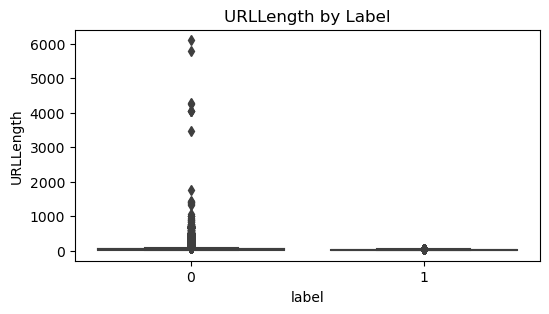

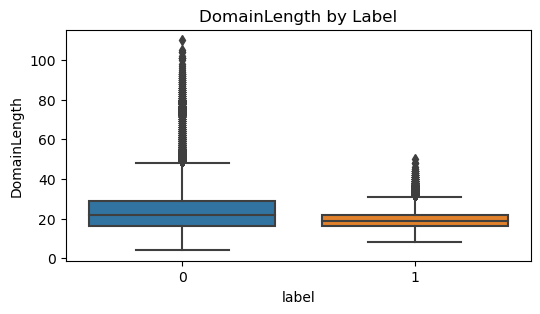

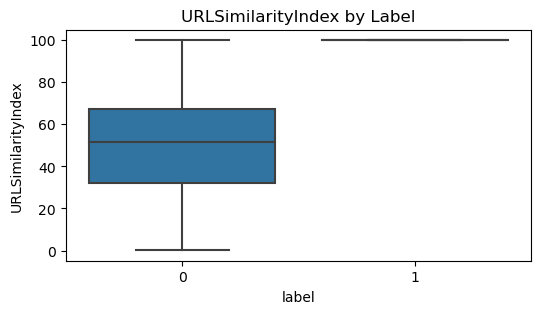

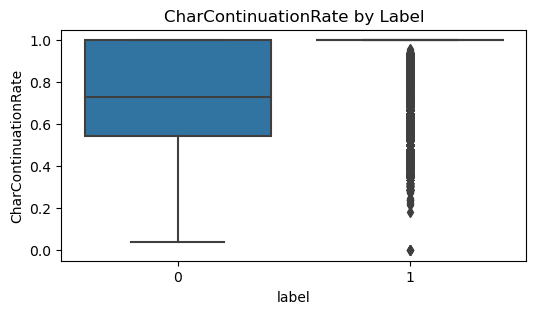

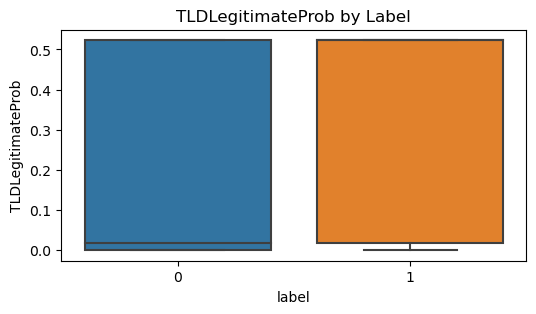

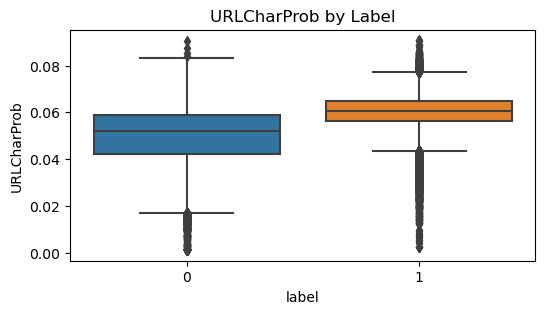

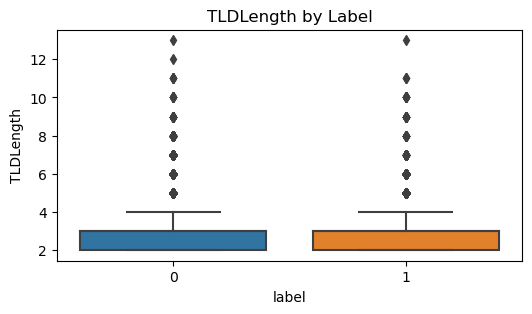

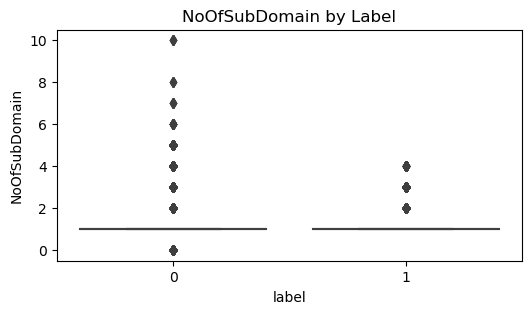

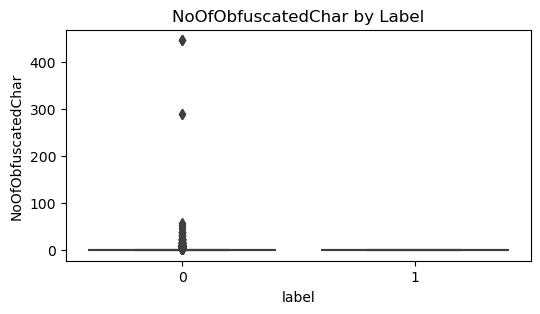

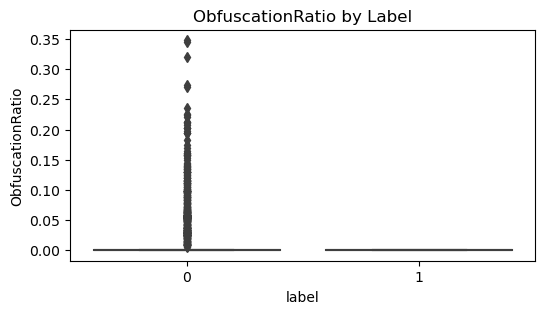

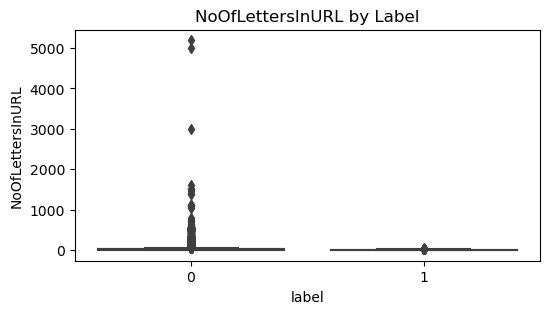

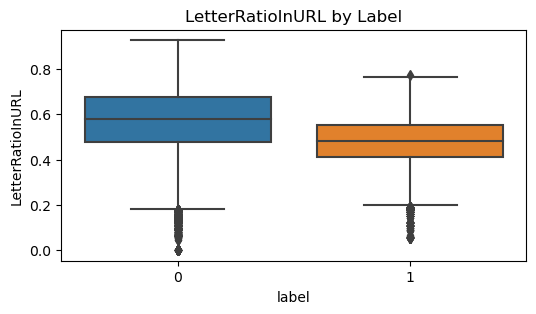

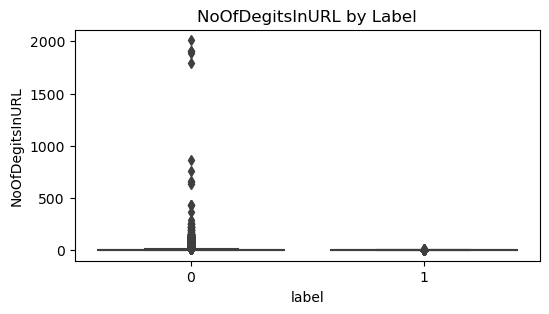

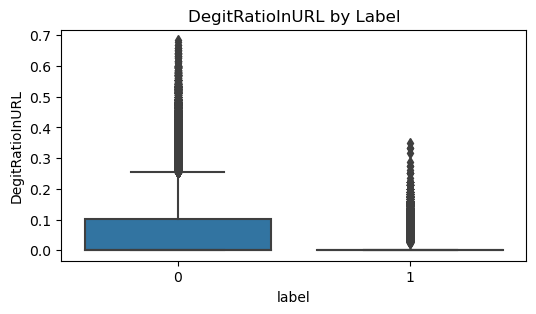

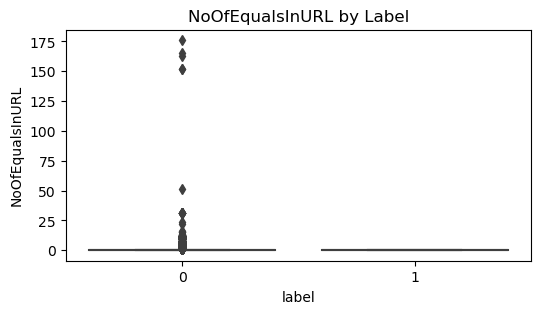

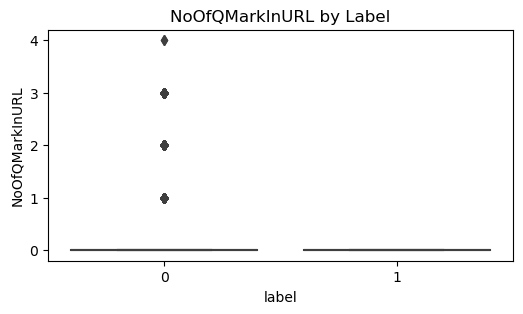

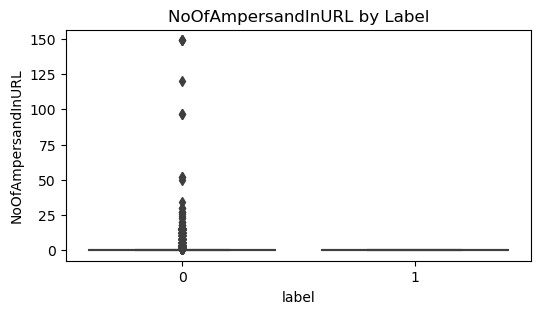

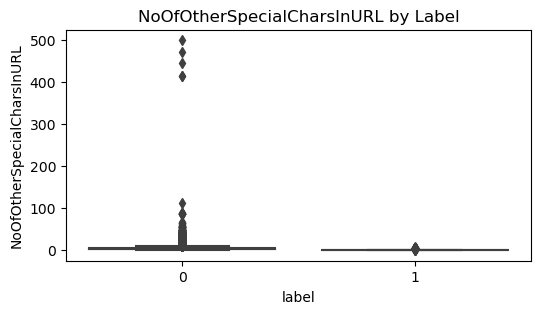

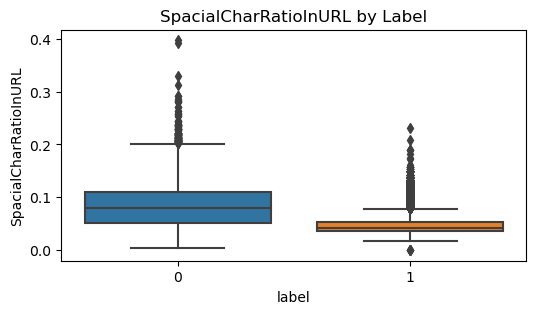

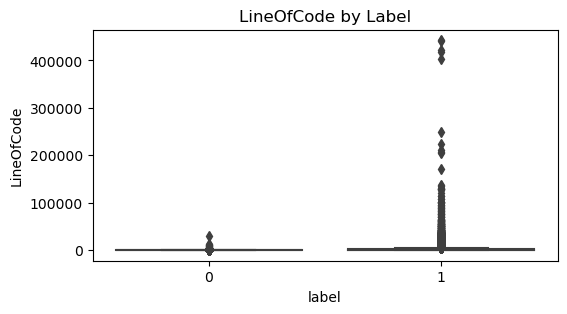

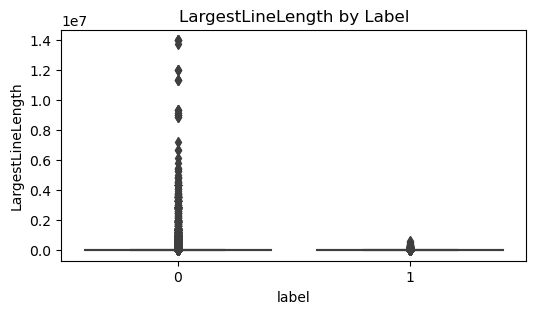

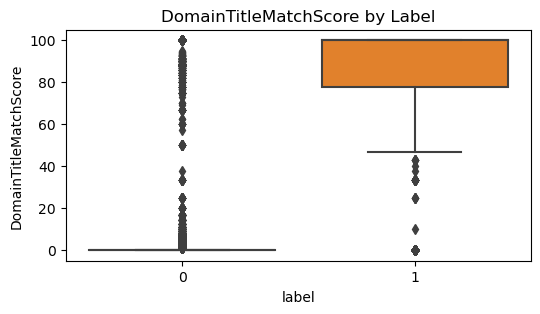

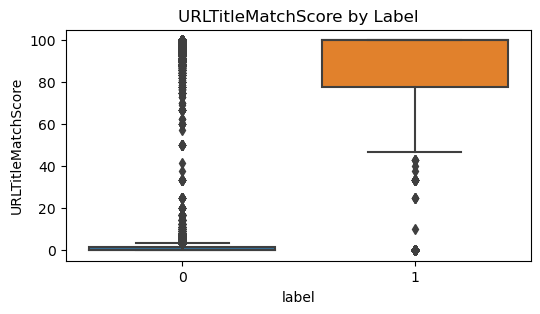

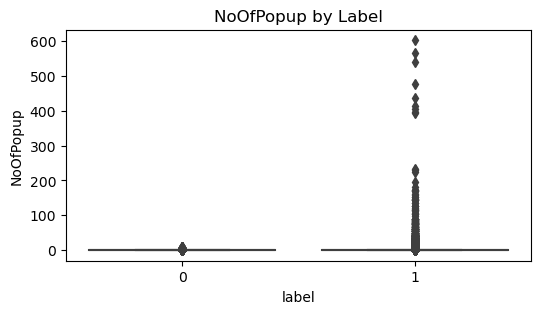

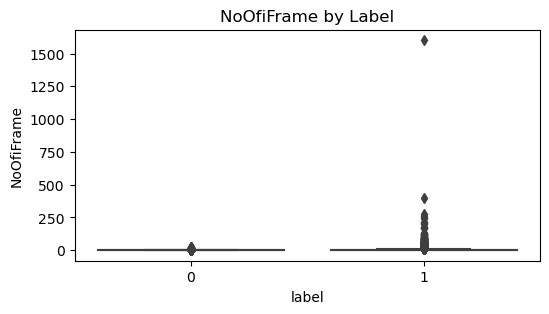

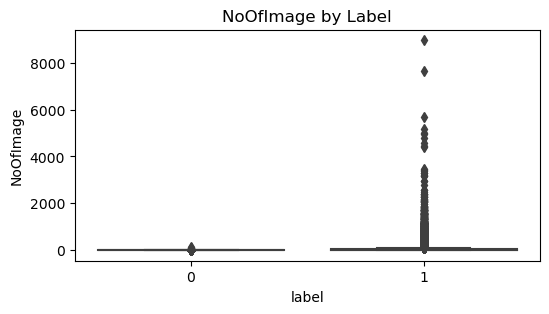

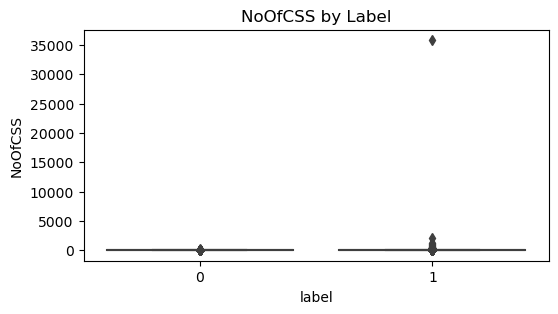

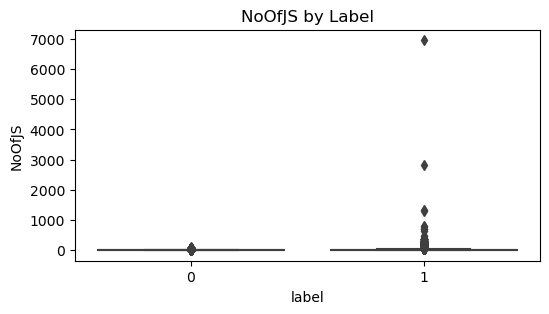

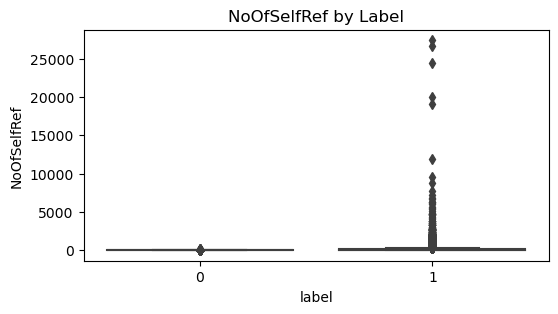

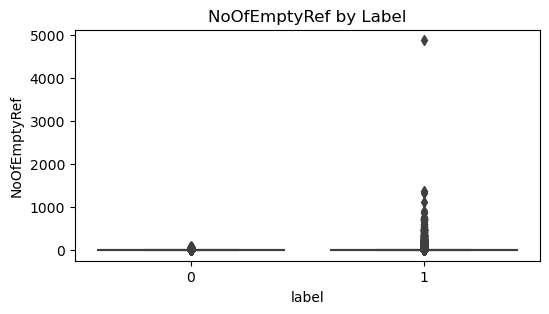

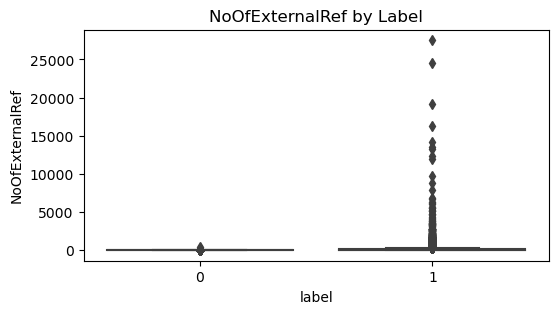

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x='label', y=col, data=df)
    plt.title(f"{col} by Label")
    plt.show()


### Relationship between label and binary_categorical_cols

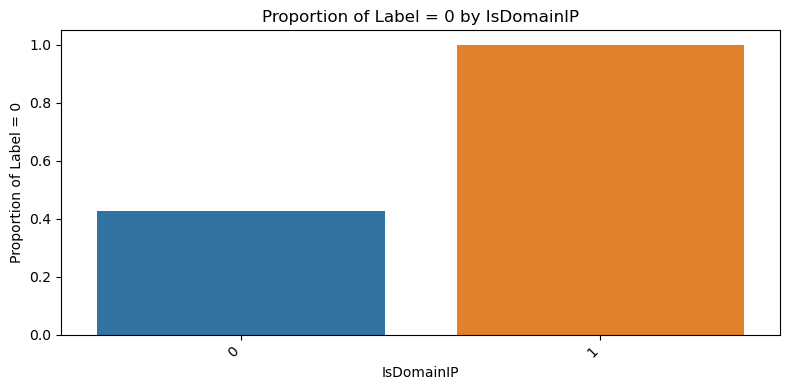

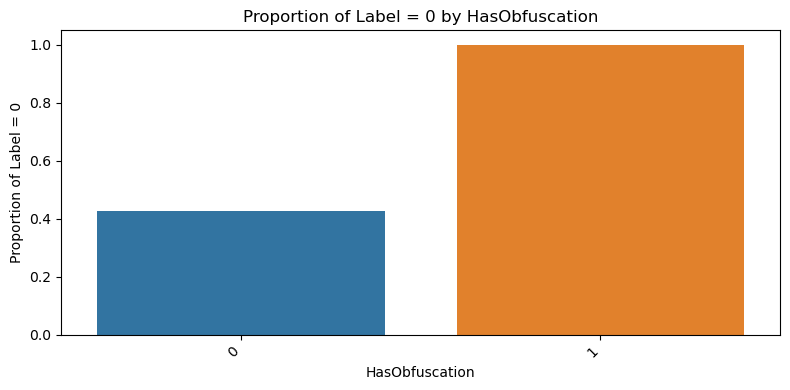

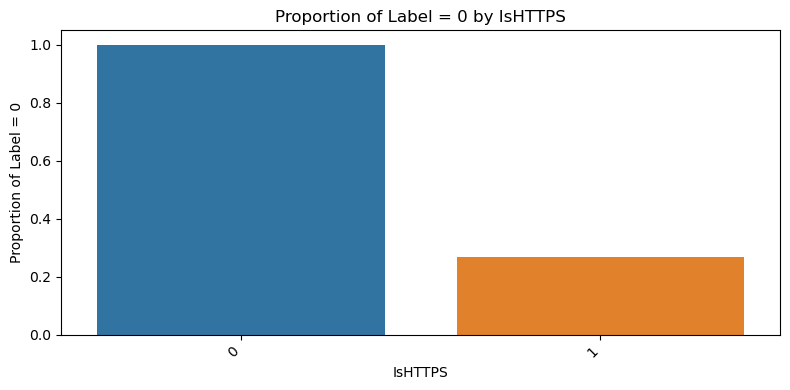

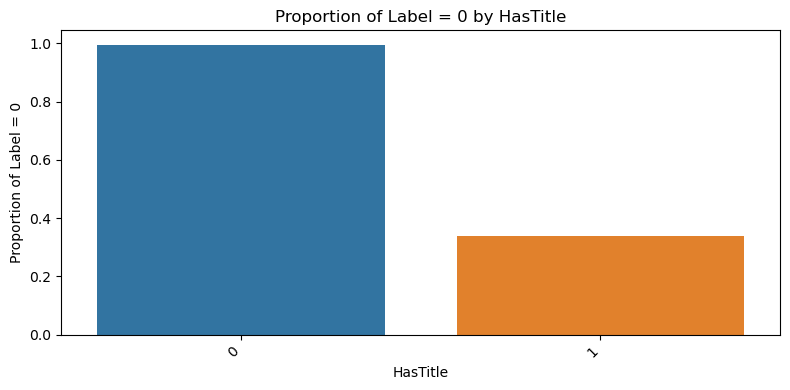

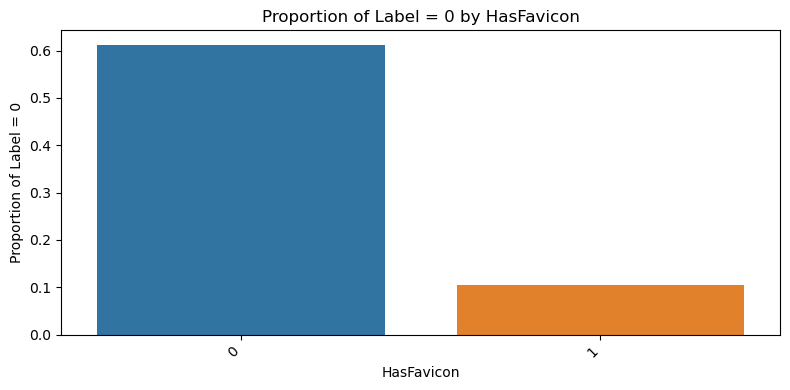

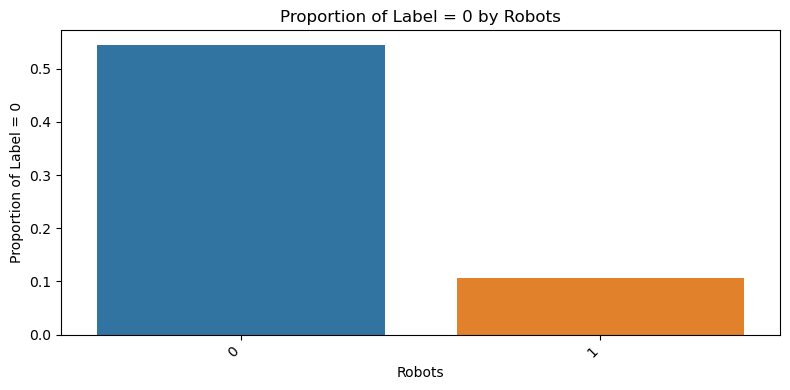

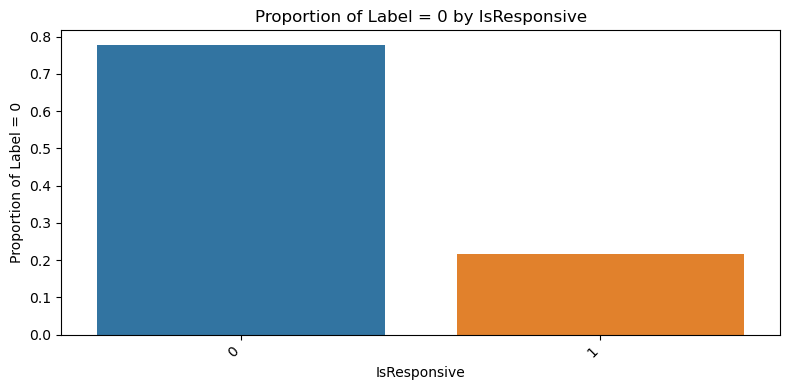

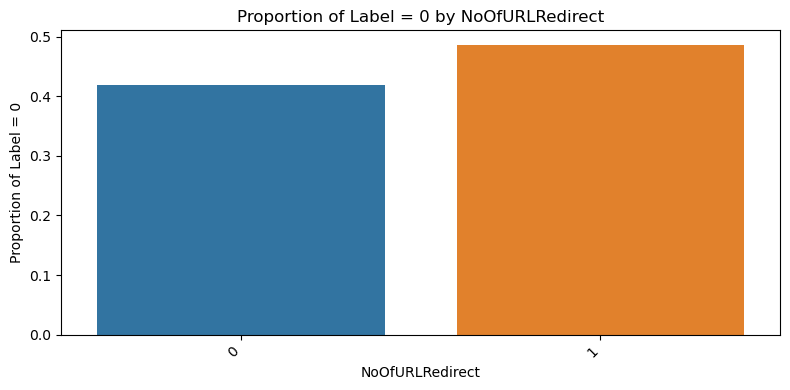

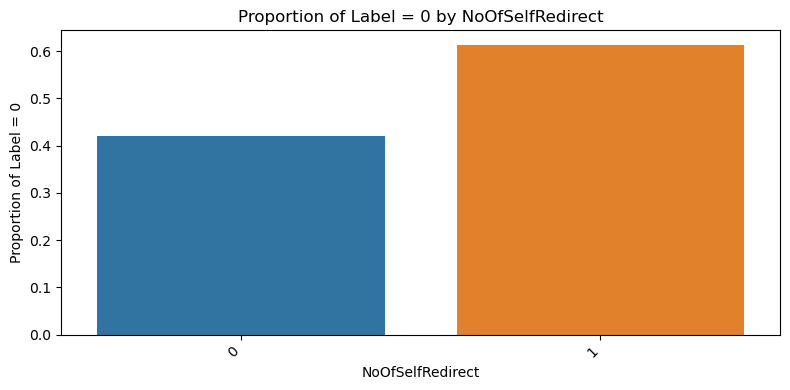

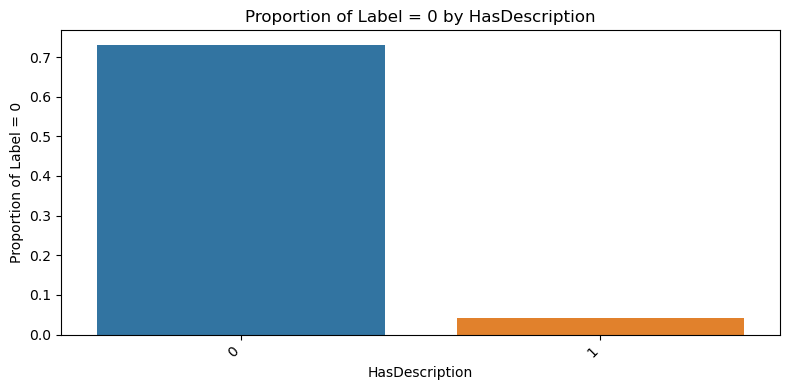

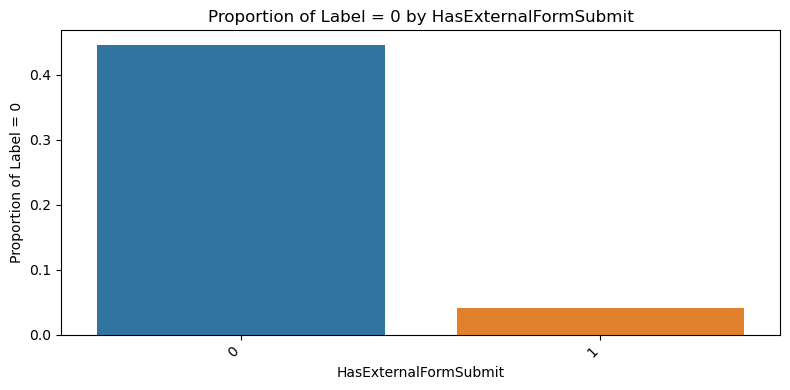

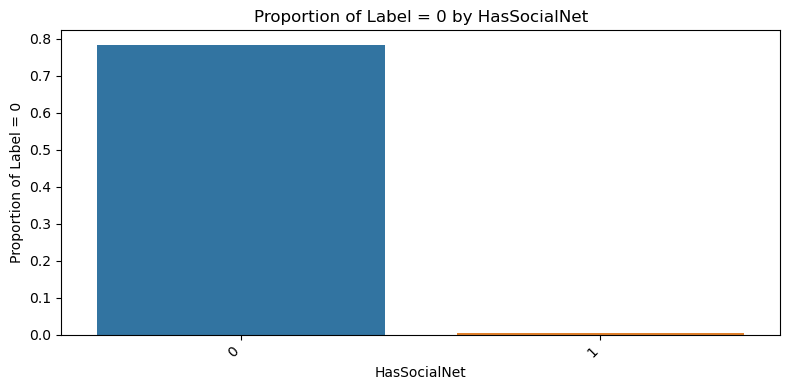

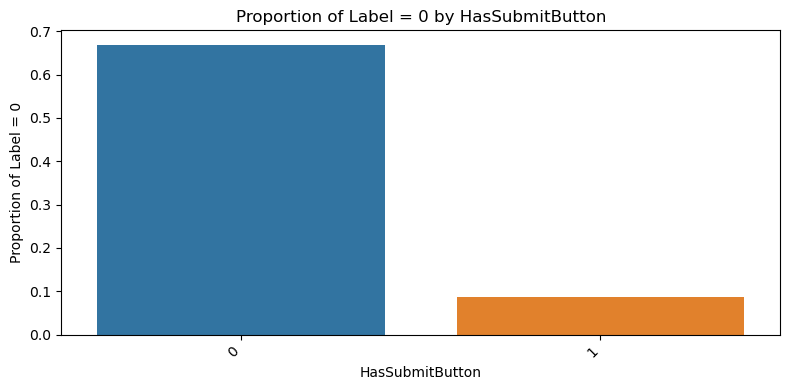

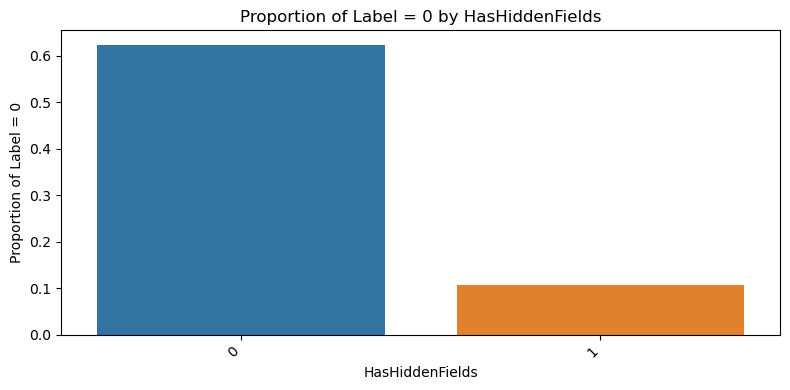

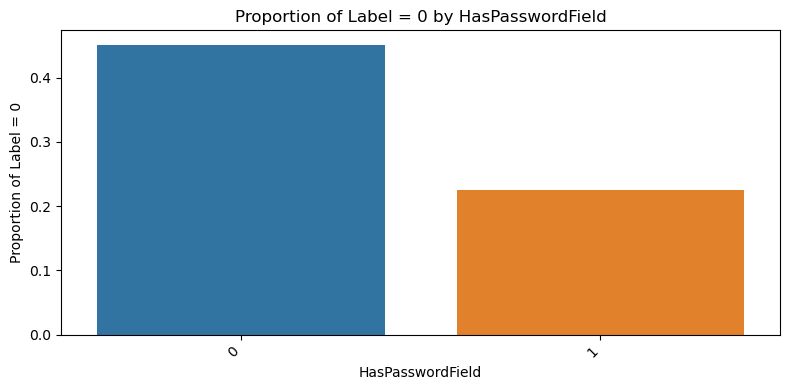

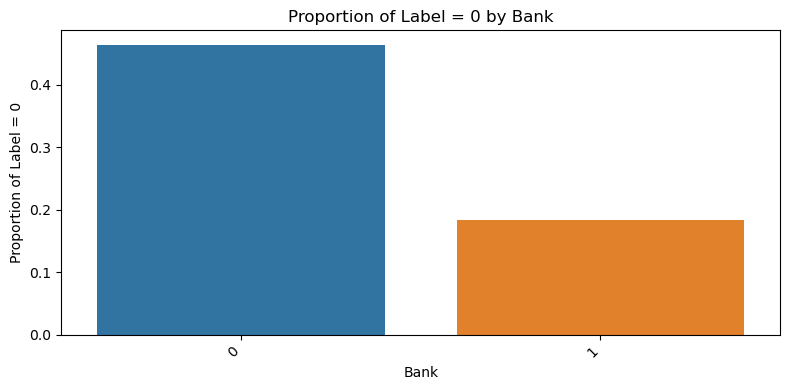

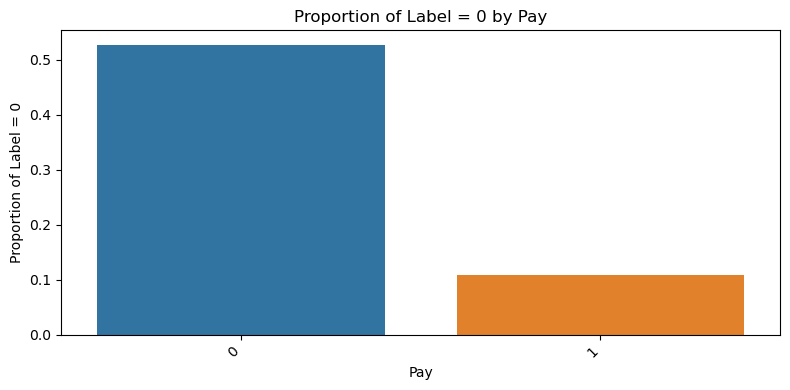

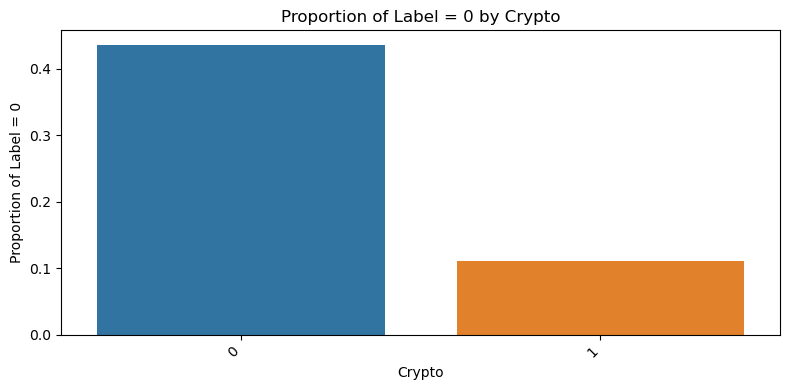

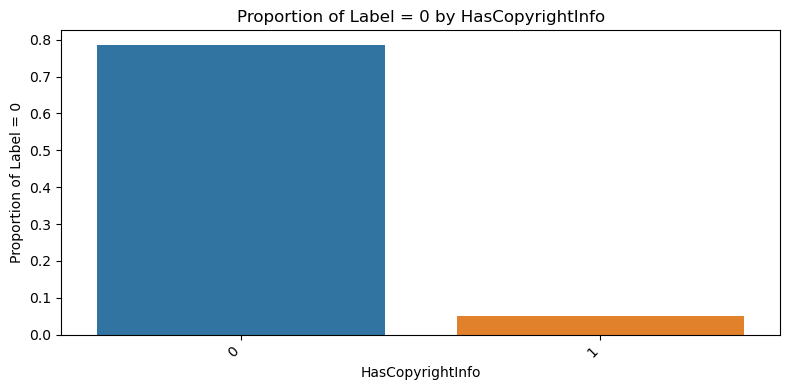

Skipping label due to error: cannot insert label, already exists


In [24]:
for col in binary_categorical_cols:
    try:
        # Group by the column and compute proportion of label == 0
        prop_df = df.groupby(col)['label'].apply(lambda x: (x == 0).mean()).reset_index()
        prop_df = prop_df.sort_values(by='label', ascending=False)

        plt.figure(figsize=(8, 4))
        sns.barplot(x=col, y='label', data=prop_df)
        plt.title(f'Proportion of Label = 0 by {col}')
        plt.ylabel('Proportion of Label = 0')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Skipping {col} due to error: {e}")



### Correlation Matrix

ValueError: Format specifier missing precision

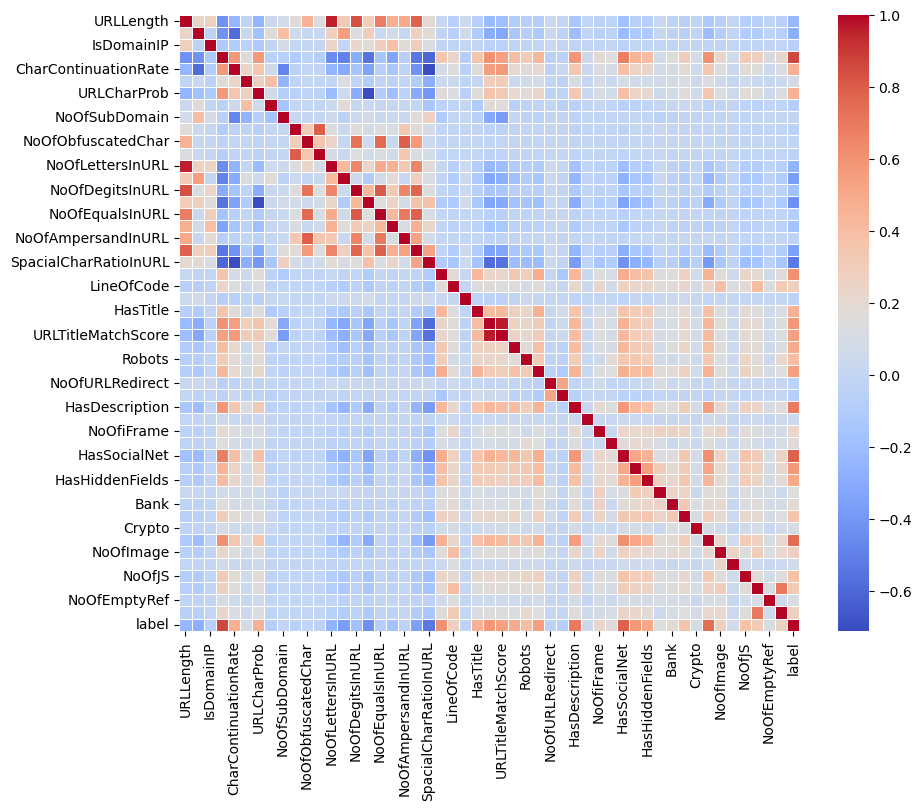

In [ ]:
corr_matrix = df[numeric_cols].corr()

#Display the correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".f", linewidths=.5)
plt.title('Correlation Matrix')
plt.xticks(rotation=30, ha='right')
plt.show()

In [25]:
print(numeric_cols)

['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


Some variables have high correlation with label.
- URLSimilarityIndex
- CharContinuationRate
- URLCharProb
- IsHTTPS
- LineOfCode
- HasTItle
- DomainTitleMatchScore
- URLTitleMatchScore
- HasFavicon
- Robots
- IsResponsive
- HasDescription
- NoOfiFrame
- HasSocialNet
- HasSubmitButton
- HasHiddenFields
- HasCopyrightInfo
- NoOfImage
- NoOfJS
- NoOfSelfRef
- NoOfExternalRef


### New features that canbe created


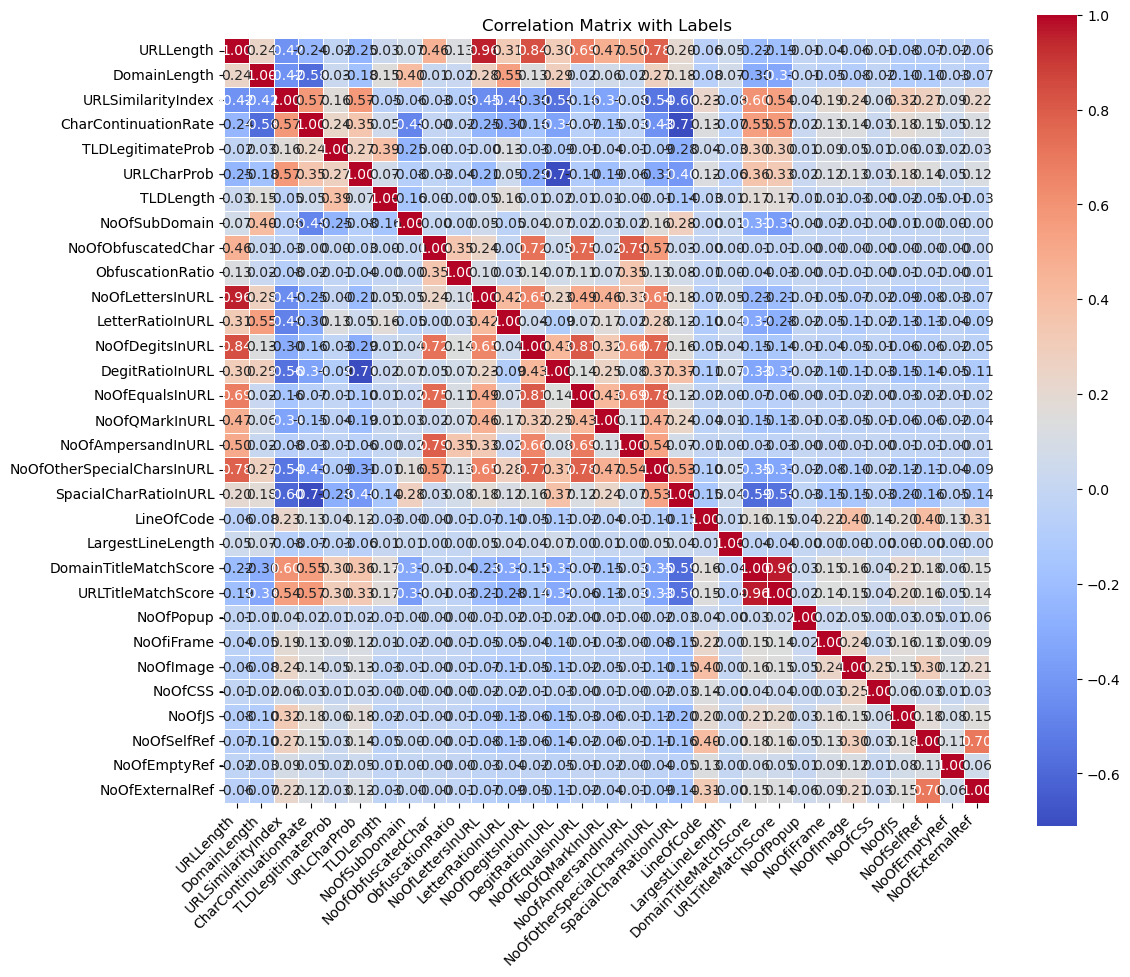

In [80]:
features = continuous_numeric_cols

corr_matrix = df[features].corr()

#Display the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title('Correlation Matrix with Labels')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
df['ObfuscationSignal'] = (df['NoOfObfuscatedChar'] + df['ObfuscationRatio']) / 2
df['URLComplexity'] = df['CharContinuationRate'] * df['SpacialCharRatioInURL']


<AxesSubplot:xlabel='label', ylabel='ObfuscationSignal'>

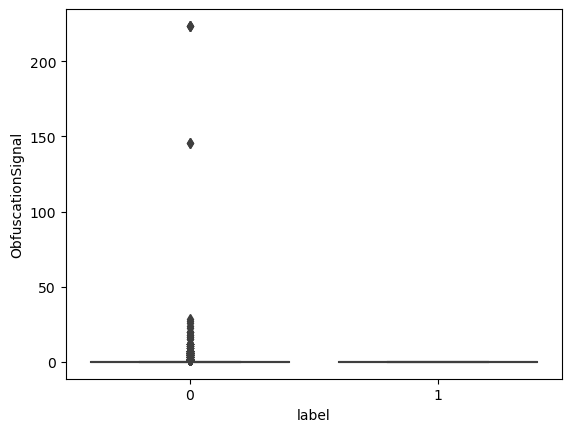

In [78]:
sns.boxplot(x='label', y='ObfuscationSignal', data=df)


In [79]:
from sklearn.feature_selection import mutual_info_classif

X = df[['ObfuscationSignal', 'URLComplexity']]
y = df['label']

mi_scores = mutual_info_classif(X, y)
print(pd.Series(mi_scores, index=X.columns))


ObfuscationSignal    0.001885
URLComplexity        0.303643
dtype: float64
